### Baseline Model Train

### 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TF-IDF vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB

# Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
# Save models
import pickle
import os

os.makedirs("../models", exist_ok=True)
os.makedirs("../outputs/plots", exist_ok=True)

import warnings
warnings.filterwarnings('ignore')

print("All imports loaded.")

All imports loaded.


### 2.Load cleaned data

In [2]:
# Load the cleaned data saved at the end of Phase 1
df = pd.read_csv("../data/processed/cleaned_news.csv")

print(f"Total samples : {len(df):,}")
print(f"Label balance :\n{df['label'].value_counts()}")
df.head(3)

Total samples : 44,898
Label balance :
label
0    23481
1    21417
Name: count, dtype: int64


,clean_content,label
0,breaking gop chairman grassley has had enough ...,0
1,failed gop candidates remembered in hilarious ...,0
2,mike pence’s new dc neighbors are hilariously ...,0


In [3]:
# Check how many nulls exist
print("Nulls before fix:", df['clean_content'].isnull().sum())

# Drop nulls and empty strings
df = df[df['clean_content'].notna()]
df = df[df['clean_content'].str.strip() != '']
df = df.reset_index(drop=True)

print("Nulls after fix :", df['clean_content'].isnull().sum())
print("Total samples   :", len(df))

Nulls before fix: 9
Nulls after fix : 0
Total samples   : 44889


### 3. Train/Test split

In [4]:
X = df['clean_content']
y = df['label']

# 80% train, 20% test — standard split
# stratify=y ensures both splits have same class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training samples : {len(X_train):,}")
print(f"Testing samples  : {len(X_test):,}")
print(f"\nTrain label dist :\n{y_train.value_counts()}")
print(f"\nTest label dist  :\n{y_test.value_counts()}")

Training samples : 35,911
Testing samples  : 8,978

Train label dist :
label
0    18777
1    17134
Name: count, dtype: int64

Test label dist  :
label
0    4695
1    4283
Name: count, dtype: int64


### 4.  TF-IDF vectorization

In [5]:
# max_features=50000 — keep top 50k most important words
# ngram_range=(1,2) — captures single words AND two-word phrases
# e.g. "not true" is captured as a bigram, which "not" + "true" separately would miss
# sublinear_tf=True — dampens very frequent words (log scaling)

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

# fit on training data only — never fit on test data
# this prevents data leakage
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

print(f"Vectorized shape — train : {X_train_vec.shape}")
print(f"Vectorized shape — test  : {X_test_vec.shape}")

# Save vectorizer — needed in Phase 5 (Gradio app)
with open("../models/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)
print("TF-IDF vectorizer saved.")

Vectorized shape — train : (35911, 50000)
Vectorized shape — test  : (8978, 50000)
TF-IDF vectorizer saved.


In [6]:
# Save feature names from TF-IDF
# Save feature names — SHAP needs these to label which words matter
feature_names = tfidf.get_feature_names_out()
np.save("../models/tfidf_feature_names.npy", feature_names)
print(f"Saved {len(feature_names):,} feature names.")

Saved 50,000 feature names.


### 5. Train and evaluate multiple models

In [7]:
# Define models to compare
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=100, random_state=42),
    "Naive Bayes"        : MultinomialNB()
}

results = {}

for name, model in models.items():
    print(f"\nTraining: {name}...")
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')

    results[name] = {"accuracy": acc, "f1_score": f1, "model": model}

    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1 Score : {f1:.4f}")


Training: Logistic Regression...
  Accuracy : 0.9926
  F1 Score : 0.9926

Training: Random Forest...
  Accuracy : 0.9943
  F1 Score : 0.9943

Training: Naive Bayes...
  Accuracy : 0.9575
  F1 Score : 0.9575


### 6. Comparison chart

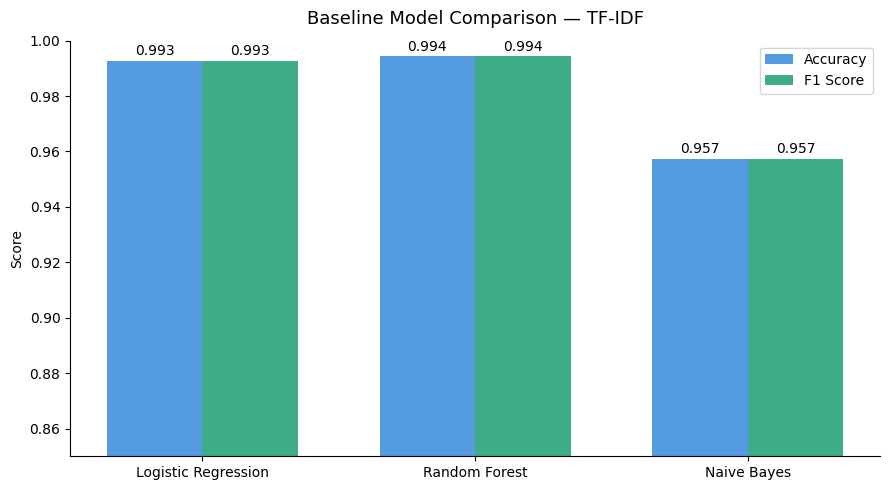

In [8]:
names     = list(results.keys())
accs      = [results[m]['accuracy'] for m in names]
f1s       = [results[m]['f1_score'] for m in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, accs, width, label='Accuracy', color='#378ADD', alpha=0.85)
bars2 = ax.bar(x + width/2, f1s,  width, label='F1 Score',  color='#1D9E75', alpha=0.85)

ax.set_title('Baseline Model Comparison — TF-IDF', fontsize=13, pad=12)
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim(0.85, 1.0)
ax.legend()

# Add score labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', fontsize=10)

sns.despine()
plt.tight_layout()
plt.savefig("../outputs/plots/baseline_comparison.png", dpi=150)
plt.show()

### 7. Detailed report on best model

=== Classification Report — Logistic Regression ===

              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      4695
        Real       0.99      0.99      0.99      4283

    accuracy                           0.99      8978
   macro avg       0.99      0.99      0.99      8978
weighted avg       0.99      0.99      0.99      8978



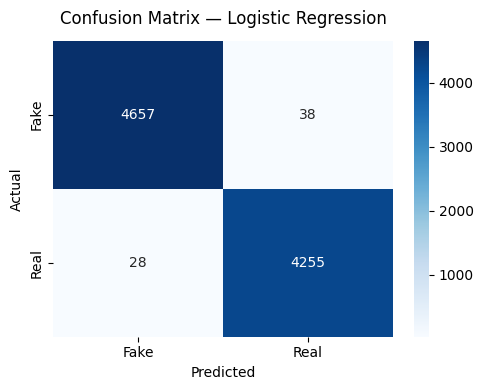

In [9]:
# Logistic Regression is almost always the strongest TF-IDF baseline
best_model = results["Logistic Regression"]["model"]
y_pred_best = best_model.predict(X_test_vec)

print("=== Classification Report — Logistic Regression ===\n")
print(classification_report(y_test, y_pred_best, target_names=["Fake", "Real"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"],
            ax=ax)
ax.set_title('Confusion Matrix — Logistic Regression', pad=12)
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig("../outputs/plots/confusion_matrix_baseline.png", dpi=150)
plt.show()

### 8. Save best model

In [10]:
with open("../models/logreg_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Logistic Regression model saved to models/logreg_model.pkl")

Logistic Regression model saved to models/logreg_model.pkl


In [11]:
# Save the training data sample for SHAP background
import scipy.sparse

# SHAP needs a background dataset to compute explanations
# We save 500 random training samples for this purpose
background_indices = np.random.choice(X_train_vec.shape[0], 500, replace=False)
background_data = X_train_vec[background_indices]

scipy.sparse.save_npz("../models/shap_background.npz", background_data)
print("SHAP background data saved.")

SHAP background data saved.


### 9. Quick inference test

In [12]:
# Load saved models and test on a custom sentence
# This is exactly what Phase 5 (Gradio app) will do

def predict_baseline(text):
    vec  = tfidf.transform([text])
    pred = best_model.predict(vec)[0]
    prob = best_model.predict_proba(vec)[0]
    label = "REAL ✅" if pred == 1 else "FAKE ❌"
    print(f"Prediction  : {label}")
    print(f"Confidence  : Fake={prob[0]:.2%}  Real={prob[1]:.2%}")

# Test it
predict_baseline("The president signed a new executive order on climate change today.")
predict_baseline("Shocking truth: government hiding alien contact since 1947.")

Prediction  : FAKE ❌
Confidence  : Fake=79.11%  Real=20.89%
Prediction  : FAKE ❌
Confidence  : Fake=90.29%  Real=9.71%
